# Project plasma-cell states in the Alameda cohort

**Biology rationale.** Reference projection provides a consistent program vocabulary across discovery and validation cohorts.

**Aim.** Apply starCAT plasma-cell programs to Alameda cells and summarize projected states.

**Data input.** `Alameda.h5ad`, `umap_usage_panels.pdf`, `cnmf_status_cat_annotation.csv`, `UMAP_origin_2char.pdf`, `GEP2_origin_2char_sample_level_values.csv`



**Data outputs.** `../cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt`, `plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv`, `GEP2_boxplot_by_origin_2char_sample_level_with_stats.pdf`, `GEP2_boxplot_by_origin_2char_sample_level_with_stats.png`

## 1. Packages and setup


In [1]:
import sys
from cnmf import cNMF
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import starCAT



In [2]:
tcat = starCAT(reference='../cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt', 
               cachedir='./query_cNMF/cache')


Using user specified reference spectra file ../cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt
No scores provided


In [3]:
tcat.ref

,PERM1,ISG15,TTLL10,TNFRSF18,TNFRSF4,TAS1R3,TMEM52,MMEL1,AL512413.1,MEGF6,...,AMELY,TBL1Y,AC064829.1,AC244213.1,AC004556.3,AC233755.2,AC233755.1,AC136616.3,AC136616.2,AC141272.1
GEP1,0.000000,0.605092,0.000000,0.000000,0.000000,0.112493,0.000000,0.000000,0.001787,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP2,0.046746,0.426410,0.000000,0.354571,0.360851,0.623126,0.449011,0.029182,0.000000,0.054676,...,0.000000,0.000000,0.000000,0.022139,0.214174,0.000000,0.230403,0.091618,0.310233,0.481726
GEP3,0.000000,0.377933,0.006809,0.508294,0.397441,0.169179,0.006413,0.000000,0.000000,0.040408,...,0.098393,0.080297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP4,0.000000,0.002521,0.000000,1.113971,0.975821,0.000000,0.000000,0.000000,0.001403,0.022440,...,0.000000,0.000000,0.059156,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP5,0.055977,0.834073,0.052521,0.239575,0.298272,0.000000,0.384284,0.009218,0.000000,0.103687,...,0.014648,0.000000,0.000000,0.925469,0.288303,0.000000,3.531507,0.000000,0.000000,0.000000
GEP6,0.003823,0.115977,0.000000,0.124212,0.261377,0.830904,0.446456,0.004871,0.045169,0.005919,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004694,0.000000,0.000000
GEP7,0.000000,0.142833,0.000000,0.679429,0.739847,0.038123,0.000000,0.002912,0.000000,0.001585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP8,0.000000,0.000000,0.000000,0.000000,0.000000,0.272512,0.122547,0.011927,0.000000,0.001070,...,0.044460,0.210256,0.000000,0.000000,0.161448,5.954403,0.000000,0.000000,0.000000,0.007968
GEP9,0.000000,0.649994,0.000000,0.000000,0.071790,0.000000,0.000000,0.202136,0.000000,0.136788,...,0.000000,0.000000,0.000000,0.005475,0.031971,0.000000,0.000000,0.000000,0.000000,0.000000
GEP10,0.000000,0.243783,0.000000,0.056349,0.142326,0.100253,0.000000,0.000000,0.000000,0.145105,...,0.000000,0.000000,0.000000,0.000000,0.173782,0.000000,0.000000,0.000000,0.005580,0.018929


In [4]:
adata = sc.read_h5ad("Alameda.h5ad")

In [5]:
# Run starCAT 
usage, _ = tcat.fit_transform(adata)


1582 out of 2000 genes in the reference overlap with the query


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/starcat/starcat.py:253: UserWarning: WARNING!: query input has 234 genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.
  warnings.warn("""WARNING!: query input has %d genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.""" % num_zeros, UserWarning)


## 2. Sample metadata and clinical groups


In [6]:
usage.head()

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9,GEP10,GEP11,GEP12,GEP13
AL_1_AAACCTGAGCTTCGCG-1,0.117503,0.004849,0.285034,0.332812,0.106603,1.529604e-04,0.139445,7.808868e-08,0.000361,0.002575,0.003202,6.187421e-05,0.007403
AL_1_AAACCTGAGGCTCATT-1,0.106684,0.047454,0.176366,0.438390,0.138597,7.731255e-02,0.000004,6.787899e-07,0.003204,0.004312,0.000031,3.180417e-06,0.007642
AL_1_AAACCTGAGGGATACC-1,0.000067,0.321760,0.543455,0.096268,0.002735,7.416837e-08,0.013263,2.243489e-08,0.000003,0.001755,0.000038,1.747473e-08,0.020656
AL_1_AAACCTGAGTGCGATG-1,0.007444,0.148357,0.315180,0.206321,0.001783,1.045875e-04,0.300561,6.510180e-07,0.003911,0.001162,0.010266,8.214451e-05,0.004827
AL_1_AAACCTGCATCGGAAG-1,0.041919,0.254124,0.469795,0.116628,0.019671,3.104697e-04,0.074708,3.072768e-04,0.000194,0.012350,0.000091,8.491530e-04,0.009053


In [7]:
adata

AnnData object with n_obs × n_vars = 58416 × 26343
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'TP11', 'TP21', 'TP31', 'TP41', 'TP51', 'TP61', 'TP71', 'TP81', 'TP91', 'TP101', 'TP111', 'TP121', 'TP131', 'TP_Max', 'TP_Max_T', 'S.Score', 'G2M.Score', 'Phase', 'old.ident'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [8]:
# Merge usages and scores with cell metadata
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)


## 3. Gene-expression program analysis


In [9]:
adata

AnnData object with n_obs × n_vars = 58416 × 26343
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'TP11', 'TP21', 'TP31', 'TP41', 'TP51', 'TP61', 'TP71', 'TP81', 'TP91', 'TP101', 'TP111', 'TP121', 'TP131', 'TP_Max', 'TP_Max_T', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP10', 'GEP11', 'GEP12', 'GEP13'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

First we plot the discrete features output by starCAT

As well as continuous scores

And we can output the continuous usages of all of the cGEPs

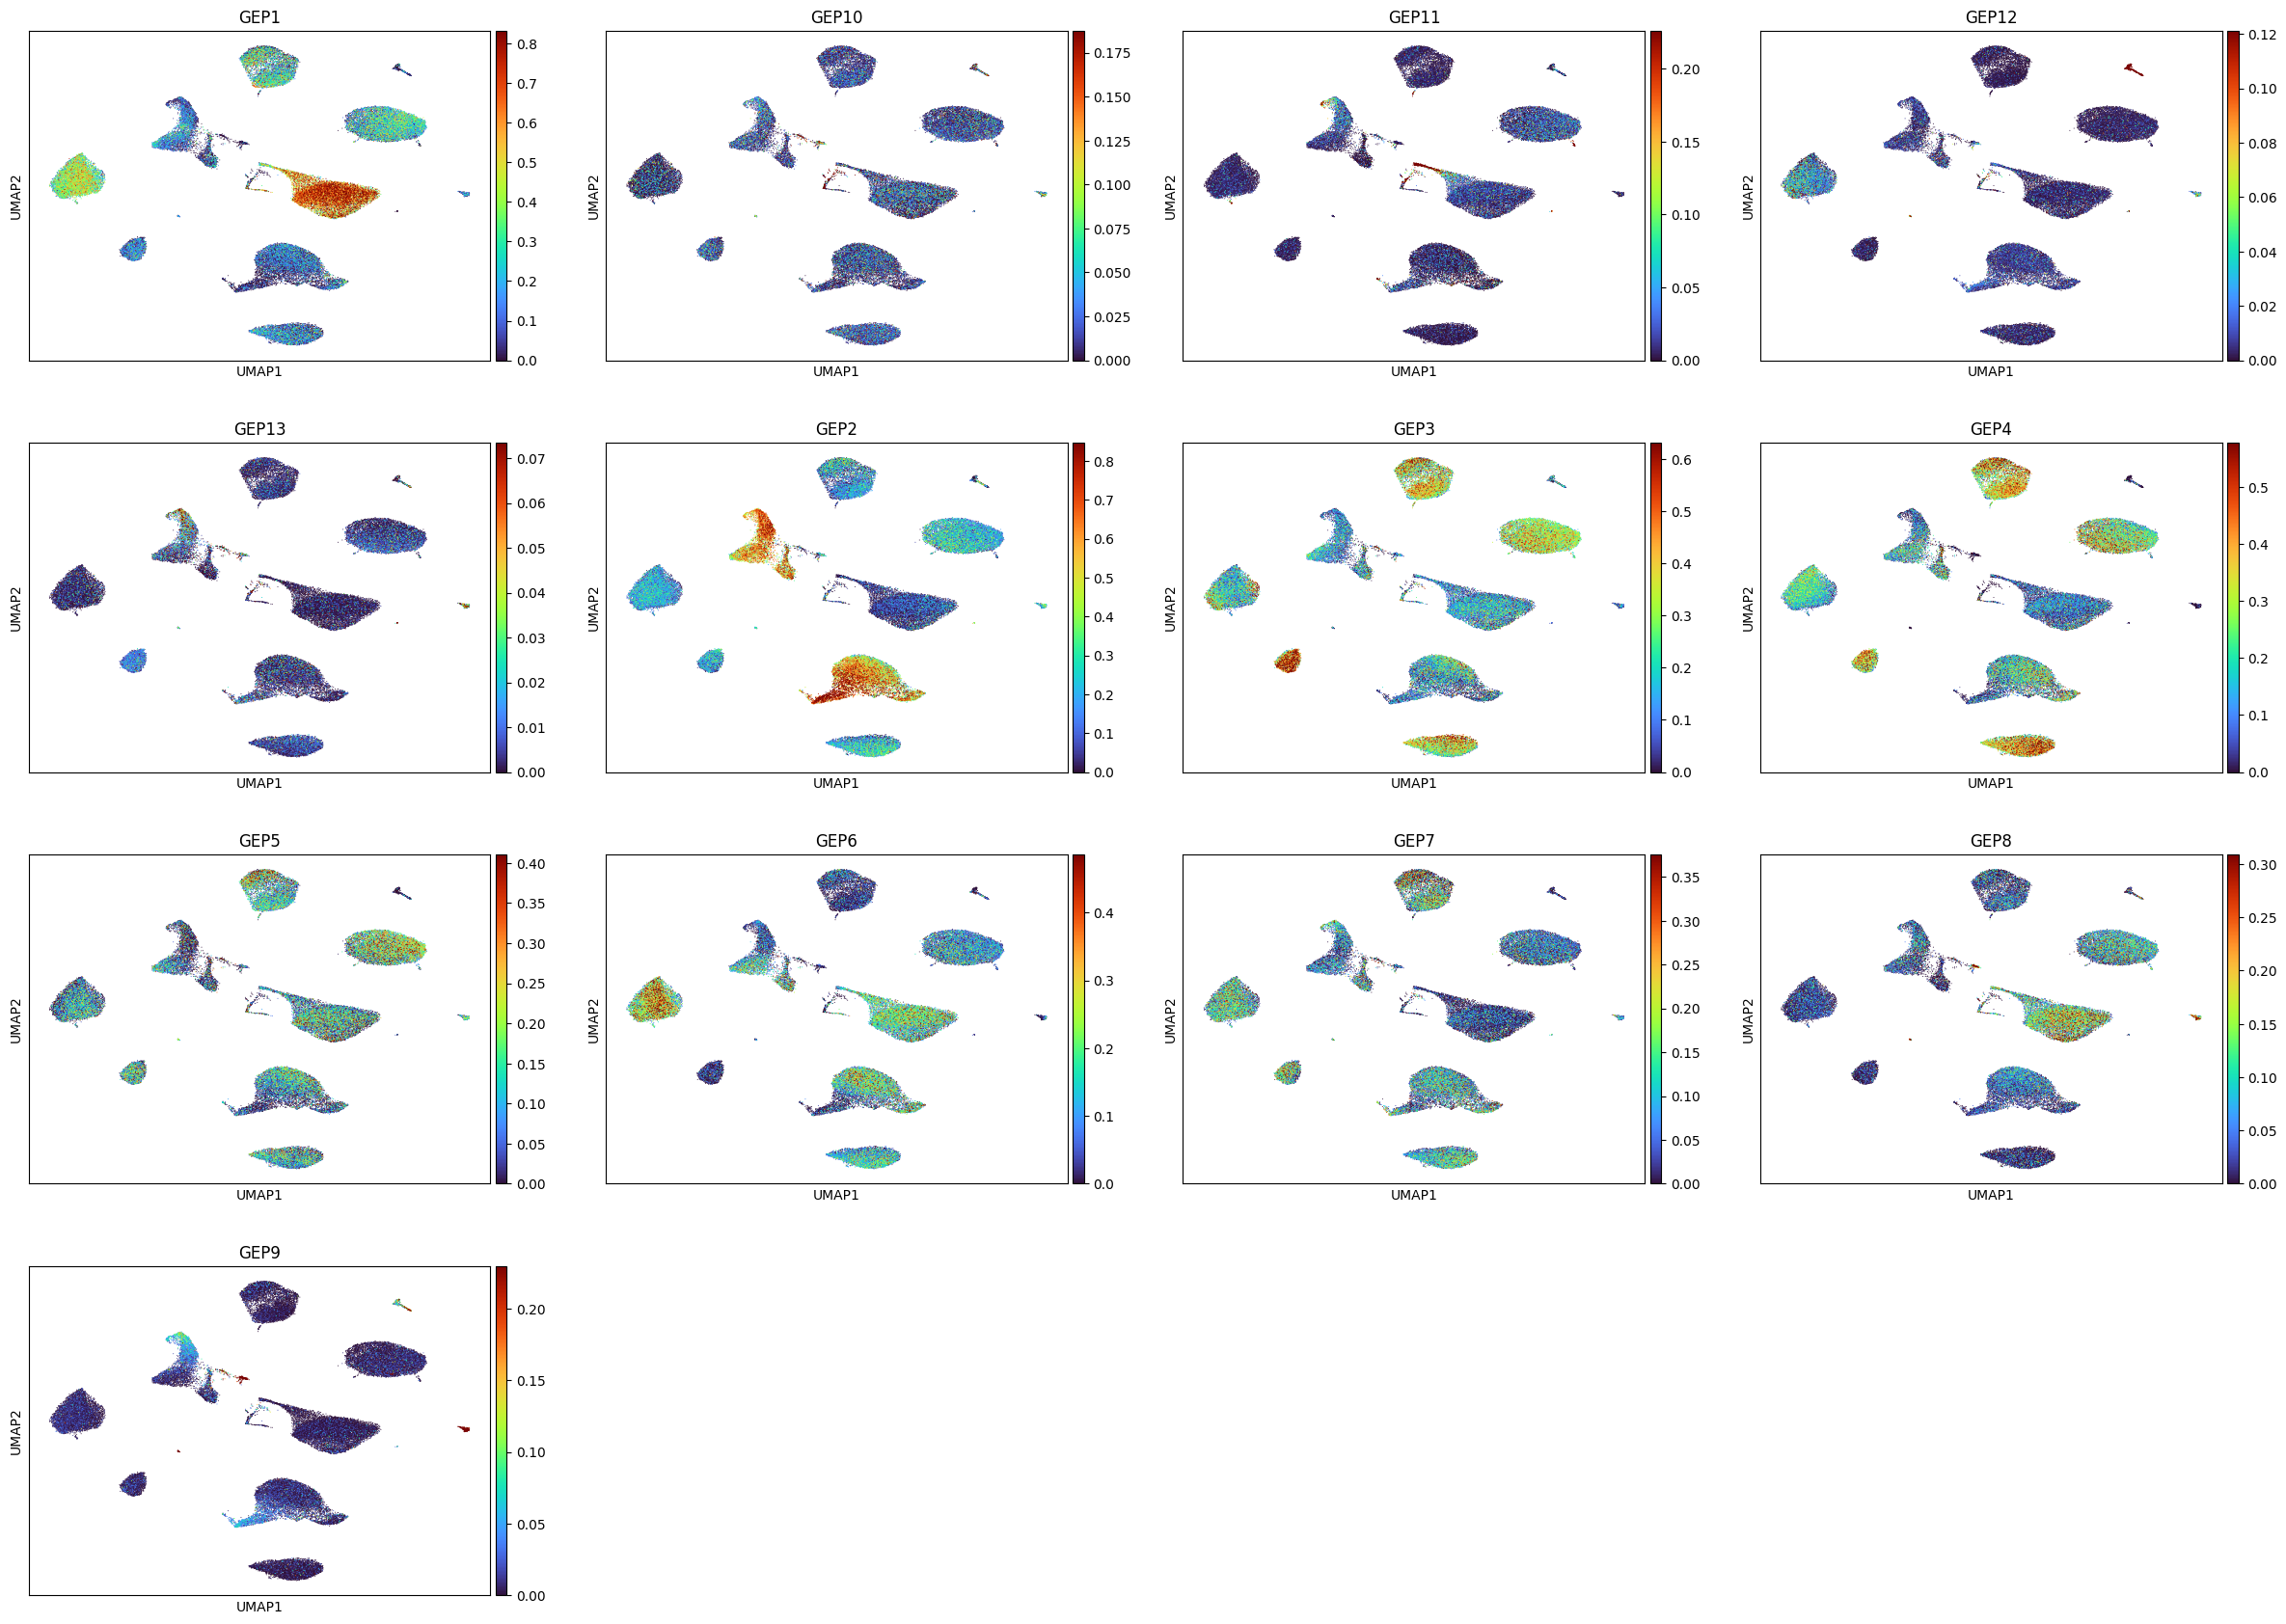

In [10]:
sc.pl.umap(adata, color=sorted(usage.columns), ncols=4, vmin=0, vmax='p99',color_map="turbo")

In [11]:
import math
import scanpy as sc
import matplotlib.pyplot as plt

# --- inputs ---
features = sorted(usage.columns)
ncols = 4
nrows = math.ceil(len(features) / ncols)

# --- make each panel more "square" by controlling inches per panel ---
panel_size = 3.2  # tune this (e.g., 2.8-4.0)
figsize = (panel_size * ncols, panel_size * nrows)

# Option A (recommended): set scanpy global figure params (works in older versions)
sc.set_figure_params(figsize=figsize)

# (Optional) tighten spacing between panels a bit
hspace = 0.35
wspace = 0.25

# --- plot (no figsize argument here) ---
sc.pl.umap(
    adata,
    color=features,
    ncols=ncols,
    vmin=0,
    vmax="p99",
    color_map="turbo",
    show=False,
    hspace=hspace,
    wspace=wspace,
)

# --- save to PDF ---
out_pdf = "umap_usage_panels.pdf"
plt.savefig(out_pdf, bbox_inches="tight")
plt.close()
print(f"Saved: {out_pdf}")


Saved: umap_usage_panels.pdf


In [12]:
import numpy as np
import pandas as pd

# --- choose the CNMF usage columns of interest ---
use_cols = ["GEP1", "GEP2", "GEP3", "GEP4", "GEP6", "GEP7", "GEP8", "GEP9","GEP11"]
present = [c for c in use_cols if c in adata.obs.columns]
if len(present) == 0:
    raise ValueError("None of the required CNMF columns are present in adata.obs")

# Subset and ensure numeric
U = adata.obs[present].apply(pd.to_numeric, errors="coerce")

# Map column name -> status number
status_map = {"GEP1":1, "GEP2":2,"GEP3":3,"GEP4":4,"GEP6":6,"GEP7":7,"GEP8":8, "GEP9":9,"GEP11":11}

# Row-wise argmax to pick the dominant component
argmax_idx = U.values.argmax(axis=1)  # returns positional index among `present`
chosen_cols = [present[i] if np.isfinite(i) else np.nan for i in argmax_idx]

# Convert chosen column names to status numbers; NaN if all four are NaN
status = []
confidence = []
for i, row in U.iterrows():
    vals = row.values.astype(float)
    if np.all(~np.isfinite(vals)):
        status.append(np.nan)
        confidence.append(np.nan)
        continue
    s = np.nansum(vals)
    m = np.nanmax(vals)
    # chosen column:
    j = np.nanargmax(vals)
    status.append(status_map[present[j]])
    # confidence = max / sum (guard zero/NaN)
    conf = (m / s) if (np.isfinite(m) and np.isfinite(s) and s > 0) else np.nan
    confidence.append(conf)

adata.obs["cnmf_status"] = pd.Series(status, index=U.index).astype("Float64")
adata.obs["cnmf_status_confidence"] = pd.Series(confidence, index=U.index).astype("Float64")

# Optional: mark low-confidence as unclassified (commented out)
# THRESH = 0.4
# mask_low = adata.obs["cnmf_status_confidence"].fillna(0) < THRESH
# adata.obs.loc[mask_low, "cnmf_status"] = pd.NA

# Make a categorical for nicer plotting (keeps numeric labels as strings)
adata.obs["cnmf_status_cat"] = (
    adata.obs["cnmf_status"]
    .astype("Int64")
    .astype(str)
    .replace({"<NA>": "NA"})
    .astype("category")
)

print(
    "Assigned cnmf_status to "
    f"{adata.obs['cnmf_status'].notna().sum()} / {adata.n_obs} cells.\n"
    "Value counts:\n",
    adata.obs["cnmf_status_cat"].value_counts(dropna=False)
)


Assigned cnmf_status to 58416 / 58416 cells.
Value counts:
 cnmf_status_cat
1     17841
2     15387
3     10607
4      8586
6      3046
7      1153
9       704
8       655
11      437
Name: count, dtype: int64


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

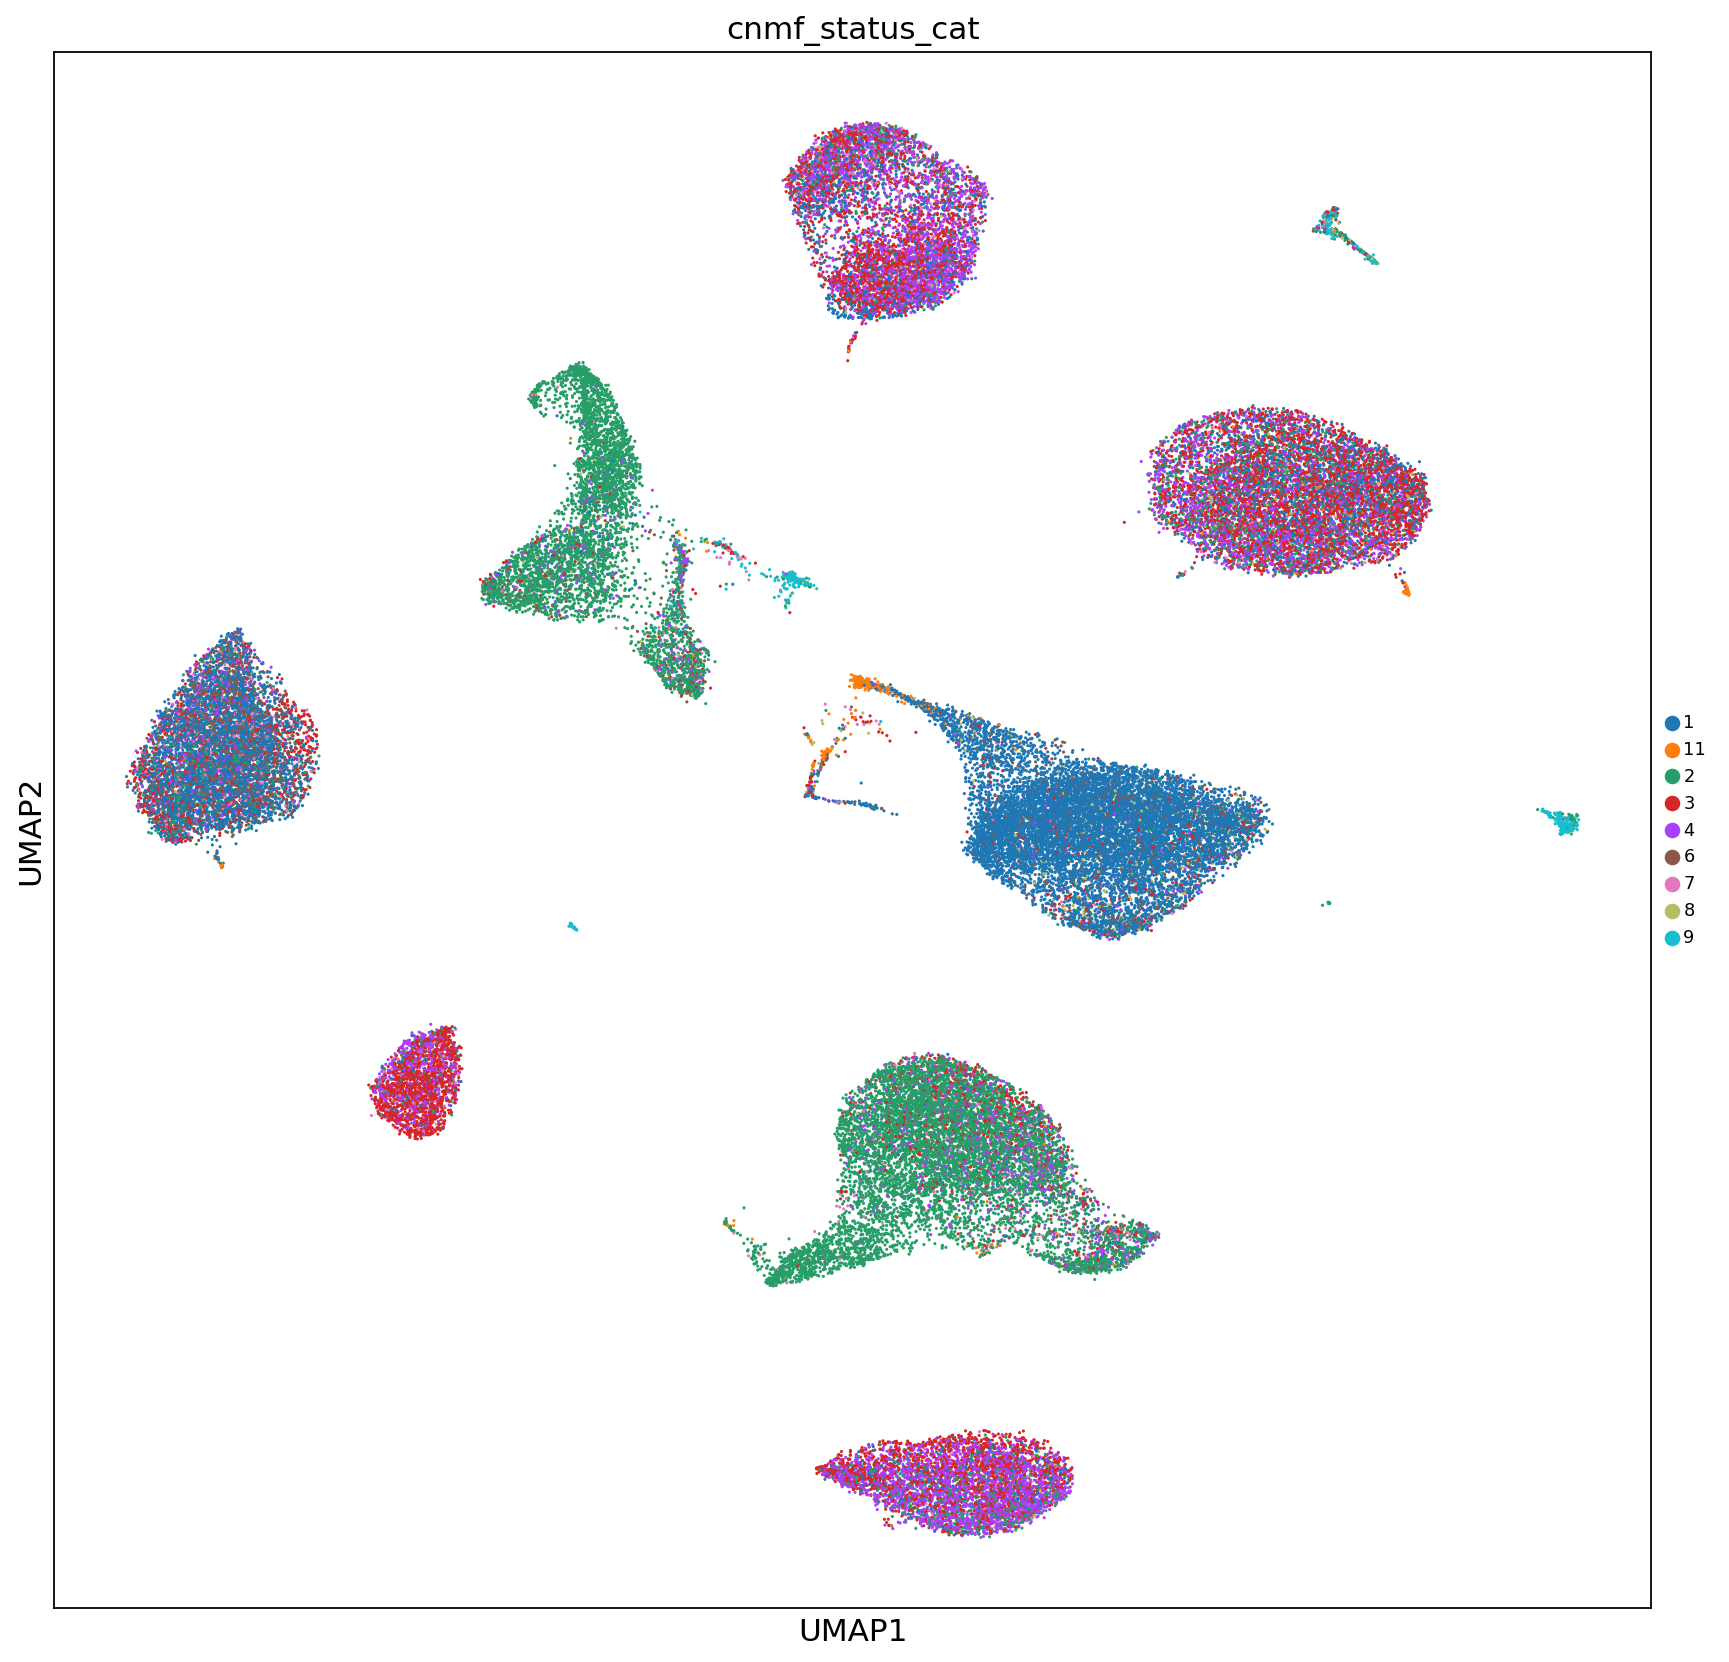

In [13]:

# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

sc.pl.umap(
    adata,
    color=["cnmf_status_cat"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)


## 4. Gene-expression program analysis


In [14]:
usage_norm = adata.obs[use_cols]

In [15]:
usage_norm.to_csv("plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv", index=True)

In [16]:
import pandas as pd

# pick the source AnnData and the column you want to transfer
src = adata
col = "cnmf_status_cat"

# export with cell barcodes (obs_names) as the key
out_csv = "cnmf_status_cat_annotation.csv"
src.obs[[col]].to_csv(out_csv, index=True)  # index=True keeps barcodes

print("Saved:", out_csv, "rows:", src.n_obs)


Saved: cnmf_status_cat_annotation.csv rows: 58416


## 5. Visualization and figure generation


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'origin'}, xlabel='UMAP1', ylabel='UMAP2'>

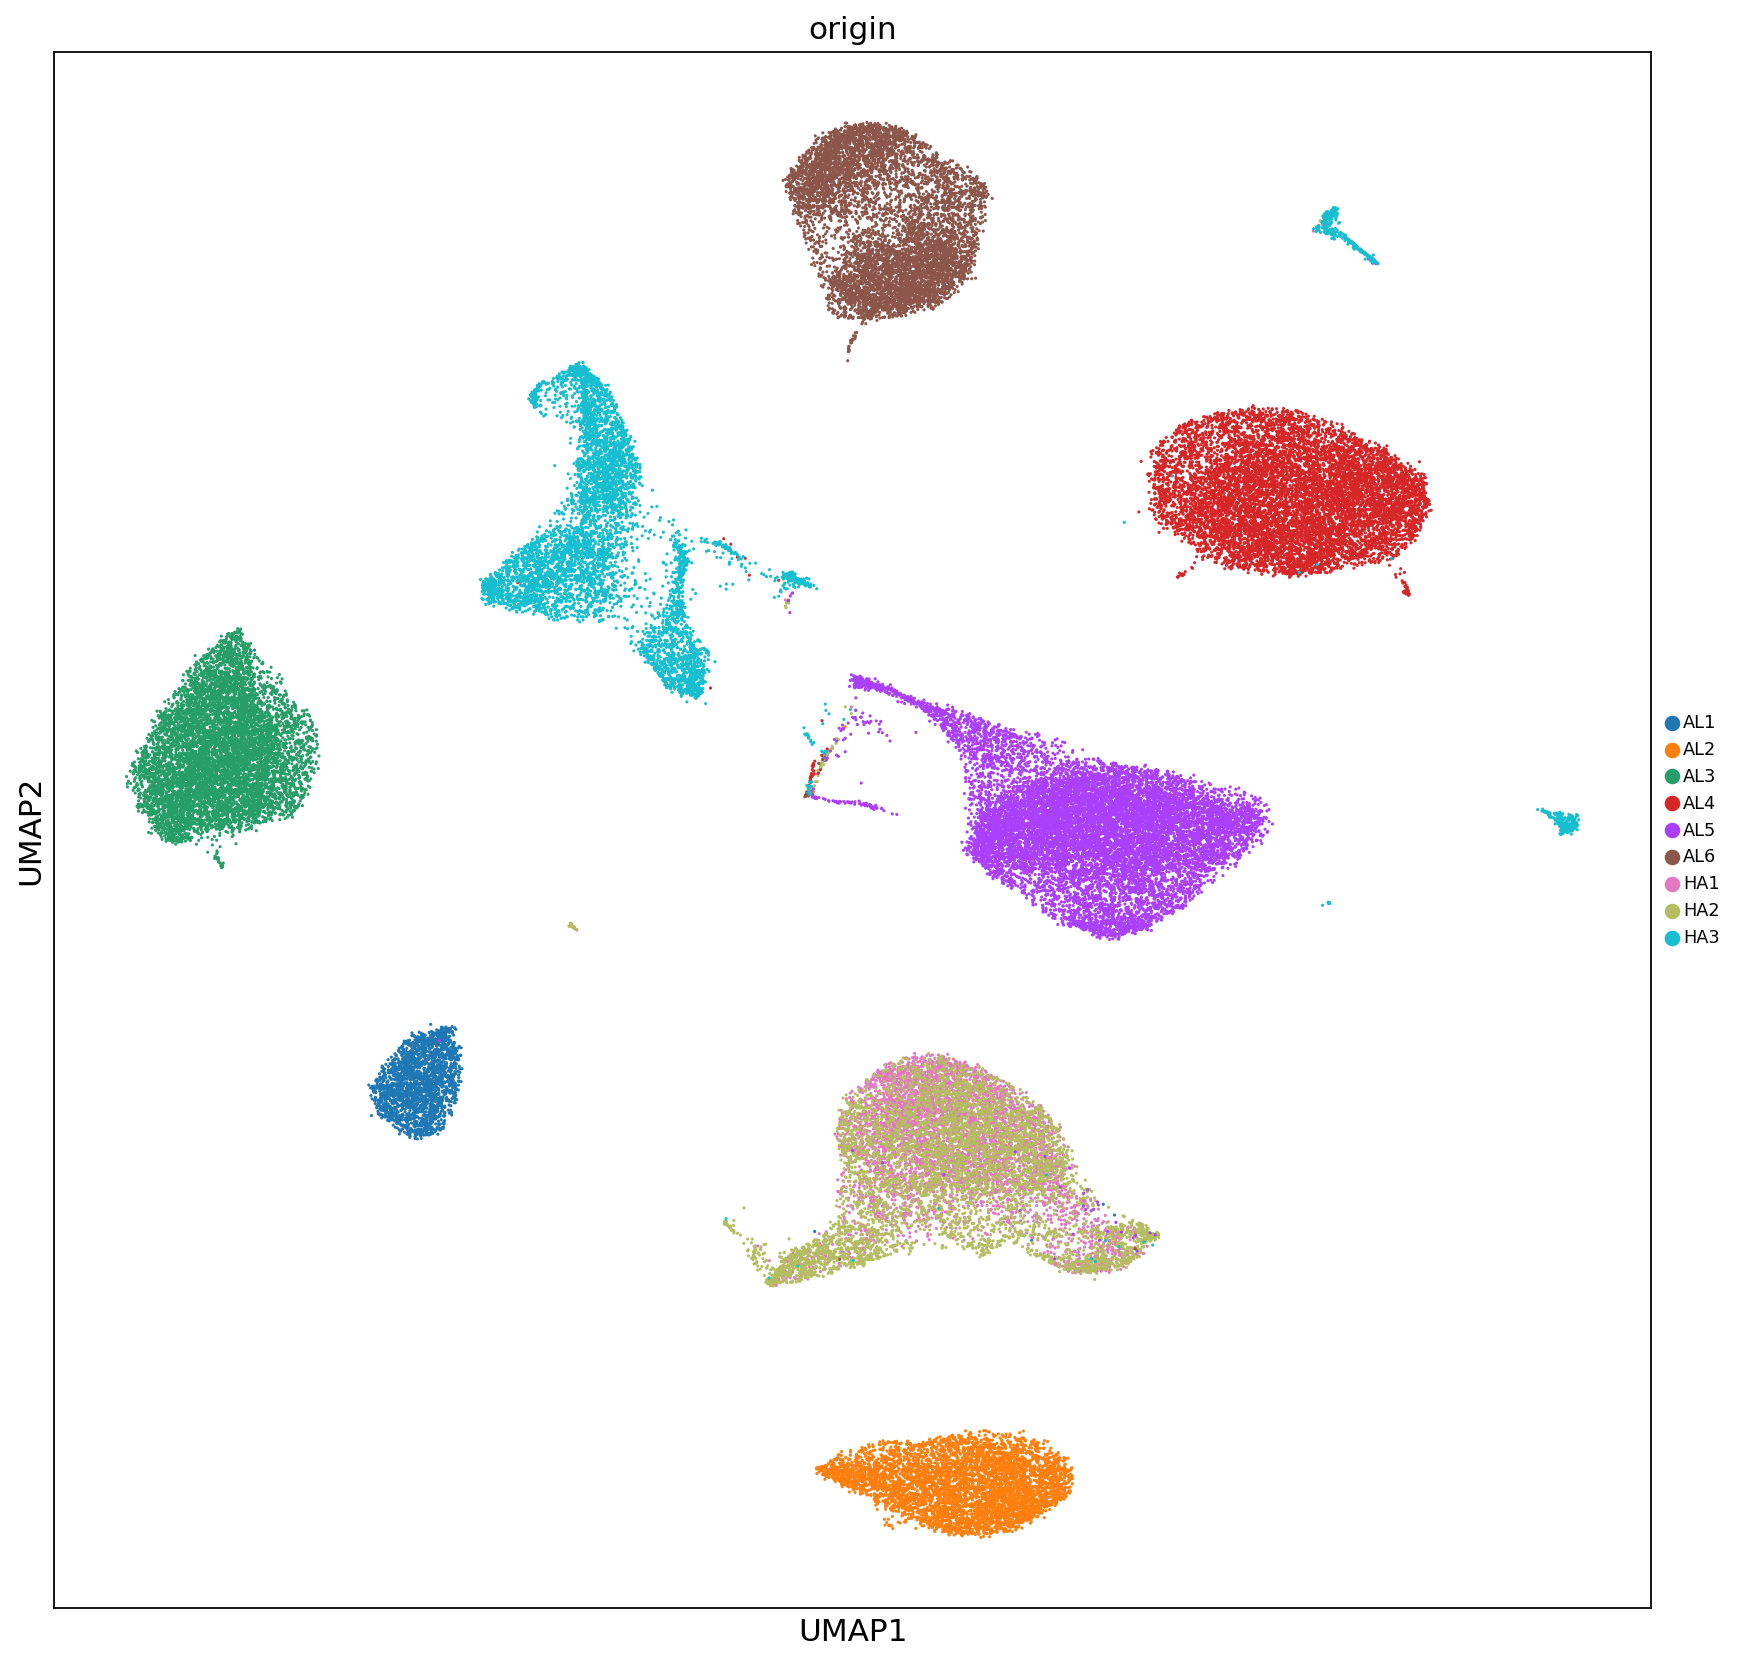

In [17]:
sc.pl.umap(
    adata,
    color=["origin"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'origin_2char'}, xlabel='UMAP1', ylabel='UMAP2'>

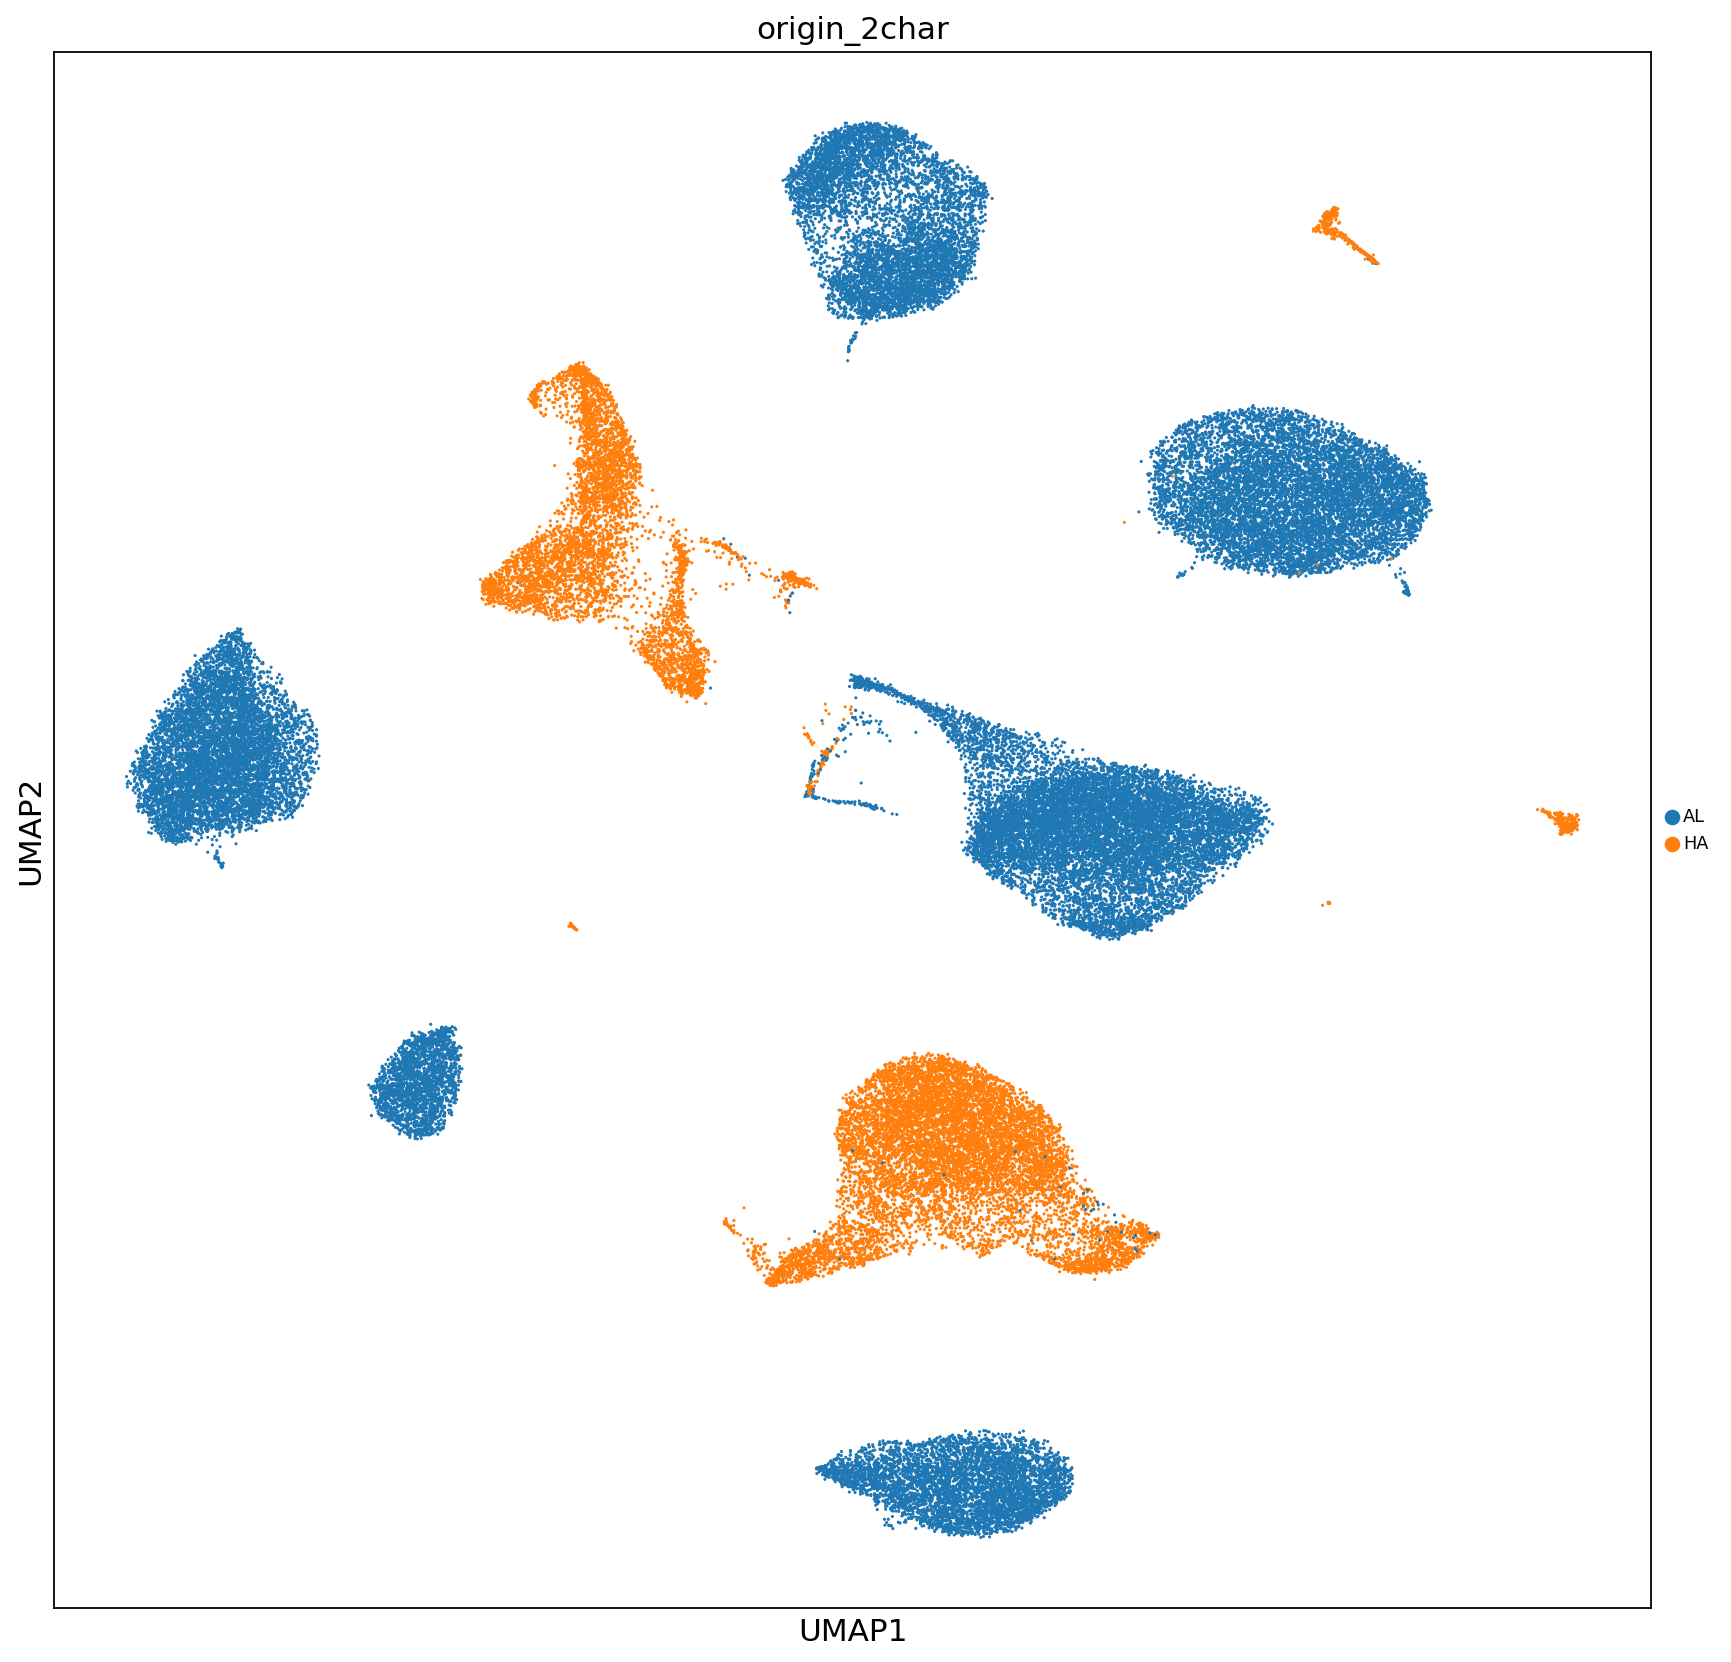

In [18]:
# Create group from first two characters of origin
adata.obs["origin_2char"] = (
    adata.obs["origin"]
    .astype(str)
    .str[:2]
    .astype("category")
)

# Plot UMAP colored by first two characters
sc.pl.umap(
    adata,
    color=["origin_2char"],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


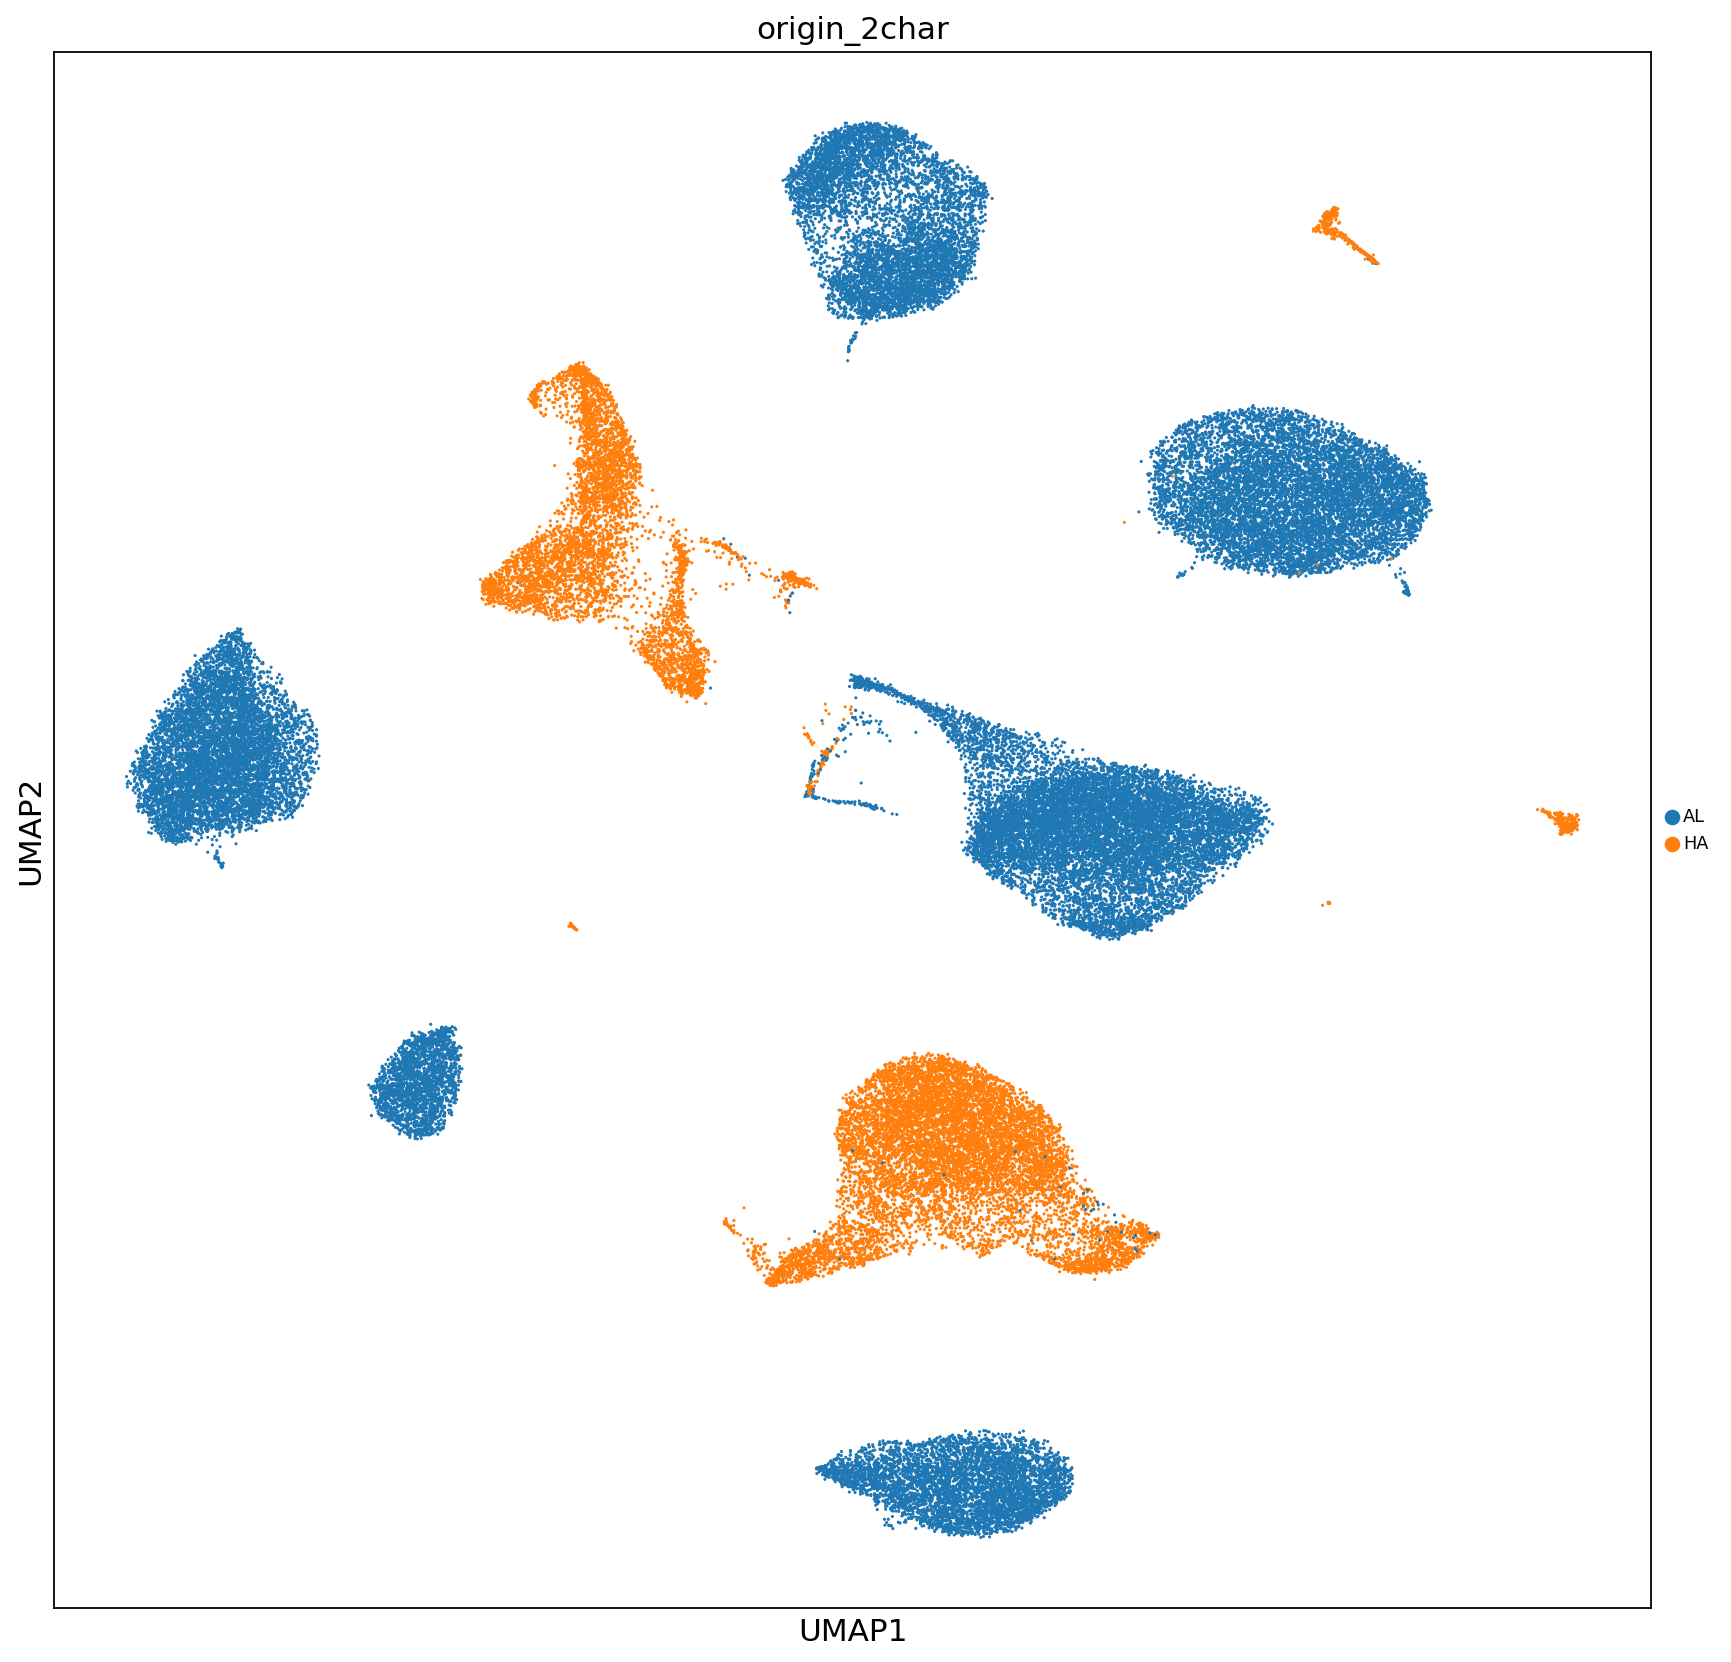


Cell counts per group:
origin_2char
AL    42129
HA    16287
Name: count, dtype: int64

Sample counts per group:
origin_2char
AL    6
HA    3
Name: count, dtype: int64

Sample-level table:


,origin,origin_2char,mean_GEP2,median_GEP2,n_cells
0,AL1,AL,0.102319,0.067572,2136
1,AL2,AL,0.137420,0.116518,5011
2,AL3,AL,0.111984,0.095195,7392
3,AL4,AL,0.133597,0.111675,9021
4,AL5,AL,0.031205,0.000761,11978
5,AL6,AL,0.092302,0.050460,6591
6,HA1,HA,0.494243,0.492666,5017
7,HA2,HA,0.459758,0.457097,5067
8,HA3,HA,0.439183,0.476600,6203



Global sample-level test:
Sample-level Mann-Whitney U: HA vs AL, p=0.0238

Pairwise sample-level tests:


,group1,group2,n_samples1,n_samples2,mean_sample_mean_GEP2_group1,mean_sample_mean_GEP2_group2,median_sample_mean_GEP2_group1,median_sample_mean_GEP2_group2,median_diff_group2_minus_group1,p_value,p_adj_BH
0,HA,AL,3,6,0.464395,0.101471,0.459758,0.107151,-0.352607,0.02381,0.02381


/tmp/ipykernel_1456123/317361853.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


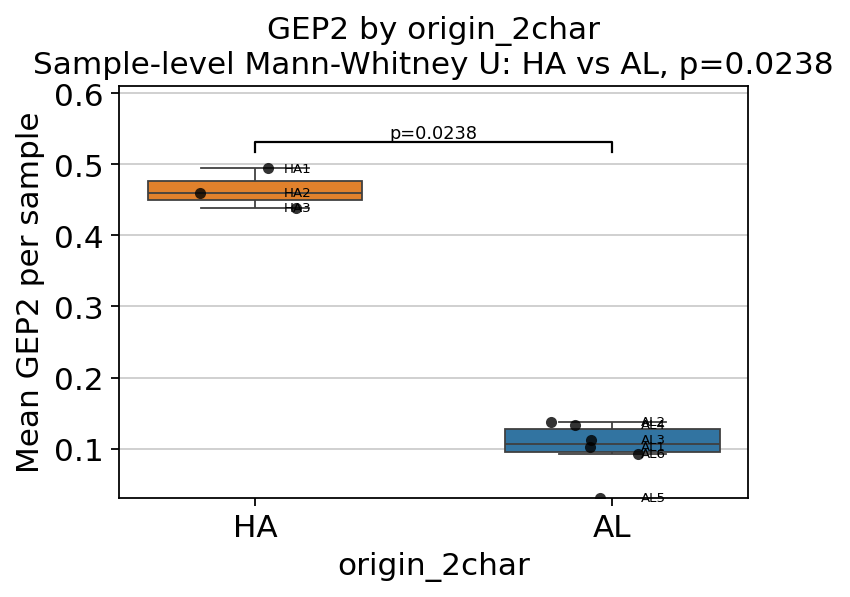

In [24]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from itertools import combinations

# ============================================================
# Helper functions
# ============================================================
def bh_adjust(pvals):
    """
    Benjamini-Hochberg FDR adjustment.
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    adjusted = ranked * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty(n)
    out[order] = adjusted
    return out


def format_p(p):
    if pd.isna(p):
        return "p=NA"
    if p < 1e-4:
        return f"p={p:.1e}"
    else:
        return f"p={p:.4f}"


def add_stat_annotation(ax, x1, x2, y, h, text):
    """
    Add bracket and p-value text to matplotlib axis.
    x1 and x2 are x-axis category positions.
    """
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1, color="black")
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=8,
        color="black"
    )


# ============================================================
# Settings
# ============================================================
score_col = "GEP2"

# Sample-level unit.
# Change this to "orig.ident" or "donor_id_global" if that is your real sample ID.
sample_col = "origin"

# Group is still based on the first two characters of origin.
group_col = "origin_2char"

# ============================================================
# 1) Create group from first two characters of origin
# ============================================================
adata.obs[group_col] = (
    adata.obs["origin"]
    .astype(str)
    .str[:2]
    .astype("category")
)

# ============================================================
# 2) UMAP colored by origin_2char
#    UMAP is still cell-level visualization only.
# ============================================================
sc.pl.umap(
    adata,
    color=[group_col],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

plt.savefig("UMAP_origin_2char.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# 3) Build cell-level dataframe
# ============================================================
df_cell = adata.obs[[score_col, sample_col, group_col]].copy()

df_cell[score_col] = pd.to_numeric(df_cell[score_col], errors="coerce")
df_cell[sample_col] = df_cell[sample_col].astype(str)
df_cell[group_col] = df_cell[group_col].astype(str)

df_cell = df_cell.dropna(subset=[score_col, sample_col, group_col])

# ============================================================
# 4) Aggregate by sample
#    Each sample contributes one value: mean GEP2.
# ============================================================
df_sample = (
    df_cell
    .groupby([sample_col, group_col], observed=True)
    .agg(
        mean_GEP2=(score_col, "mean"),
        median_GEP2=(score_col, "median"),
        n_cells=(score_col, "size")
    )
    .reset_index()
)

# Use mean GEP2 as sample-level value for plotting/statistics
sample_score_col = "mean_GEP2"

# Save sample-level table
df_sample.to_csv("GEP2_origin_2char_sample_level_values.csv", index=False)

print("\nCell counts per group:")
print(df_cell[group_col].value_counts())

print("\nSample counts per group:")
print(df_sample[group_col].value_counts())

print("\nSample-level table:")
display(df_sample)

# ============================================================
# 5) Match Scanpy category order and colors
# ============================================================
order = [
    g for g in adata.obs[group_col].cat.categories.astype(str)
    if g in df_sample[group_col].astype(str).unique()
]

# Swap left/right order in the boxplot and downstream annotations
order = order[::-1]

palette = dict(zip(
    list(adata.obs[group_col].cat.categories.astype(str)),
    adata.uns[f"{group_col}_colors"]
))

# ============================================================
# 6) Statistical tests at sample level
# ============================================================
valid_groups = [
    g for g in order
    if df_sample.loc[df_sample[group_col] == g, sample_score_col].notna().sum() > 0
]

if len(valid_groups) < 2:
    global_p = np.nan
    global_label = "Not enough groups for statistical test"

elif len(valid_groups) == 2:
    g1, g2 = valid_groups

    x = df_sample.loc[df_sample[group_col] == g1, sample_score_col].dropna()
    y = df_sample.loc[df_sample[group_col] == g2, sample_score_col].dropna()

    test = stats.mannwhitneyu(x, y, alternative="two-sided")
    global_p = test.pvalue
    global_label = f"Sample-level Mann-Whitney U: {g1} vs {g2}, {format_p(global_p)}"

else:
    arrays = [
        df_sample.loc[df_sample[group_col] == g, sample_score_col].dropna()
        for g in valid_groups
    ]

    test = stats.kruskal(*arrays)
    global_p = test.pvalue
    global_label = f"Sample-level Kruskal-Wallis: {format_p(global_p)}"

print("\nGlobal sample-level test:")
print(global_label)

# Pairwise sample-level Mann-Whitney tests
pairwise_results = []

for g1, g2 in combinations(valid_groups, 2):
    x = df_sample.loc[df_sample[group_col] == g1, sample_score_col].dropna()
    y = df_sample.loc[df_sample[group_col] == g2, sample_score_col].dropna()

    if len(x) > 0 and len(y) > 0:
        test = stats.mannwhitneyu(x, y, alternative="two-sided")
        p_value = test.pvalue
    else:
        p_value = np.nan

    pairwise_results.append({
        "group1": g1,
        "group2": g2,
        "n_samples1": len(x),
        "n_samples2": len(y),
        "mean_sample_mean_GEP2_group1": x.mean(),
        "mean_sample_mean_GEP2_group2": y.mean(),
        "median_sample_mean_GEP2_group1": x.median(),
        "median_sample_mean_GEP2_group2": y.median(),
        "median_diff_group2_minus_group1": y.median() - x.median(),
        "p_value": p_value
    })

pairwise_df = pd.DataFrame(pairwise_results)

if len(pairwise_df) > 0:
    pairwise_df["p_adj_BH"] = bh_adjust(pairwise_df["p_value"].values)
    pairwise_df = pairwise_df.sort_values("p_adj_BH")

print("\nPairwise sample-level tests:")
display(pairwise_df)

pairwise_df.to_csv(
    "GEP2_origin_2char_pairwise_sample_level_MannWhitney_BH.csv",
    index=False
)

# ============================================================
# 7) Plot sample-level boxplot
# ============================================================
plt.figure(figsize=(5, 4))
ax = plt.gca()

sns.boxplot(
    data=df_sample,
    x=group_col,
    y=sample_score_col,
    order=order,
    palette=palette,
    showfliers=False,
    width=0.6,
    linewidth=0.8,
    ax=ax
)

sns.stripplot(
    data=df_sample,
    x=group_col,
    y=sample_score_col,
    order=order,
    color="black",
    size=5,
    jitter=0.18,
    alpha=0.8,
    ax=ax
)

plt.xlabel("origin_2char")
plt.ylabel("Mean GEP2 per sample")
plt.title(f"GEP2 by origin_2char\n{global_label}")

# Optional: label each sample point
for _, row in df_sample.iterrows():
    x_pos = order.index(row[group_col])
    y_pos = row[sample_score_col]
    ax.text(
        x_pos + 0.08,
        y_pos,
        row[sample_col],
        fontsize=6,
        ha="left",
        va="center"
    )

# ============================================================
# 8) Add pairwise p-value annotation
# ============================================================
if len(order) <= 4 and len(pairwise_df) > 0:
    ymin = df_sample[sample_score_col].min()
    ymax = df_sample[sample_score_col].max()
    yrange = ymax - ymin

    if yrange == 0:
        yrange = 1

    base_y = ymax + 0.05 * yrange
    h = 0.03 * yrange
    step = 0.10 * yrange

    for annot_i, (_, row) in enumerate(pairwise_df.iterrows()):
        g1 = row["group1"]
        g2 = row["group2"]

        x1 = order.index(g1)
        x2 = order.index(g2)

        y = base_y + annot_i * step
        text = format_p(row["p_adj_BH"])

        add_stat_annotation(ax, x1, x2, y, h, text)

    ax.set_ylim(ymin, base_y + len(pairwise_df) * step + 0.1 * yrange)

plt.tight_layout()

plt.savefig("GEP2_boxplot_by_origin_2char_sample_level_with_stats.pdf", bbox_inches="tight")
plt.savefig("GEP2_boxplot_by_origin_2char_sample_level_with_stats.png", dpi=300, bbox_inches="tight")
plt.show()